# Banana gradient flow — PyTorch, Colab, GIF & MP4

This notebook rebuilds the supplied MATLAB experiment as a clean, vectorized
PyTorch workflow. All particles live in one tensor, the gradient is obtained
by automatic differentiation, and the same animation can be exported with
deterministic timing to both GIF and H.264 MP4.

**What is improved**

- a continuous definition at the two endpoints of the banana;
- PyTorch autograd instead of finite differences;
- CPU, Apple Silicon (MPS), and CUDA support;
- explicit playback speed and robust behavior at stationary points;
- reusable rendering and export functions;
- a visual style that keeps the original parula-like field while making the
  trajectories easier to read.

> Run all cells in order. In Colab, no local MATLAB file is needed.

## 1. Mathematical model

Let

$$
d(x)=x-\operatorname{clip}(x,0,1),\qquad
z_a(x,y)=y+a\left(x-\tfrac12\right)^2,
$$

and define the banana potential

$$
F_a(x,y)=d(x)^2+z_a(x,y)^2.
$$

The bend parameter is $a$. The zero set is the curved segment
$y=-a(x-\tfrac12)^2$, $0\le x\le1$.

The MATLAB animation follows the **normalized** negative gradient,

$$
\dot p=-\frac{\nabla F_a(p)}{\|\nabla F_a(p)\|},
$$

so particles move at nearly constant speed. This is slightly different from
the classical gradient flow $\dot p=-\nabla F_a(p)$; both modes are available
below. The background displays $\sqrt{F_a}$, exactly as in the source.

## 2. Imports, device, and visual theme

In [1]:
from __future__ import annotations

import importlib
import math
import os
import shutil
import subprocess
import sys
import time
from dataclasses import dataclass, replace
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, Markdown, Video, display
from matplotlib.animation import FFMpegWriter, FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

torch.manual_seed(0)
torch.set_grad_enabled(True)

def best_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = best_device()
DTYPE = torch.float32

PARULA_LIKE = LinearSegmentedColormap.from_list(
    "banana_parula",
    [
        "#352A87", "#3D3EB3", "#3B5DCA", "#327BD5",
        "#2798D2", "#1EB2C4", "#2CC7A1", "#58D179",
        "#8BD34E", "#BED33A", "#E2CE35", "#F3B532", "#F59A2F",
    ],
    N=256,
)

print(f"PyTorch {torch.__version__} · device={DEVICE} · dtype={DTYPE}")

PyTorch 2.10.0 · device=mps · dtype=torch.float32


## 3. Configuration

In [2]:
@dataclass(frozen=True)
class FlowConfig:
    bend: float = 1.0
    mode: str = "normalized"       # "normalized" or "gradient"
    particles_per_axis: int = 9
    n_frames: int = 130
    substeps: int = 20
    frame_step: float = 0.025
    freeze_tolerance: float = 1e-8
    grid_size: int = 501
    contour_levels: int = 25
    fps: int = 20
    figure_pixels: int = 640

    xlim: tuple[float, float] = (-1.0, 2.0)
    ylim: tuple[float, float] = (-2.0, 2.0)

    def __post_init__(self):
        if self.mode not in {"normalized", "gradient"}:
            raise ValueError("mode must be 'normalized' or 'gradient'")
        if self.particles_per_axis < 2 or self.n_frames < 1 or self.substeps < 1:
            raise ValueError("particle, frame, and substep counts must be positive")

cfg = FlowConfig(
    bend=1.0,
    mode="normalized",
    n_frames=130,
    substeps=20,
    fps=20,
)

display(Markdown(
    f"**Run:** bend `{cfg.bend:.2f}` · `{cfg.mode}` flow · "
    f"`{cfg.particles_per_axis**2}` particles · `{cfg.n_frames + 1}` states · "
    f"`{cfg.fps}` fps"
))

**Run:** bend `1.00` · `normalized` flow · `81` particles · `131` states · `20` fps

## 4. Vectorized PyTorch potential and autograd flow

In [3]:
def banana_potential(points: torch.Tensor, bend: float | torch.Tensor) -> torch.Tensor:
    """Evaluate F_a for an array whose last dimension is (x, y)."""
    x, y = points.unbind(dim=-1)
    distance_to_segment = x - x.clamp(0.0, 1.0)
    shifted_y = y + bend * (x - 0.5).square()
    return distance_to_segment.square() + shifted_y.square()


def initial_particles(config: FlowConfig, device: torch.device = DEVICE) -> torch.Tensor:
    # Same 9x9 interior grid as the MATLAB source, generalized to q x q.
    q = config.particles_per_axis
    xs = torch.linspace(*config.xlim, q + 2, device=device, dtype=DTYPE)[1:-1]
    ys = torch.linspace(*config.ylim, q + 2, device=device, dtype=DTYPE)[1:-1]
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    return torch.stack((xx.reshape(-1), yy.reshape(-1)), dim=-1)


@torch.enable_grad()
def potential_gradient(points: torch.Tensor, bend: float) -> torch.Tensor:
    p = points.detach().requires_grad_(True)
    total_energy = banana_potential(p, bend).sum()
    (gradient,) = torch.autograd.grad(total_energy, p, create_graph=False)
    return gradient.detach()


def simulate_flow(
    config: FlowConfig,
    seeds: torch.Tensor | None = None,
    device: torch.device = DEVICE,
) -> torch.Tensor:
    """Return [frame, particle, xy] on CPU; particles update in parallel."""
    points = initial_particles(config, device) if seeds is None else seeds.to(device, DTYPE)
    history = [points.detach().cpu()]
    substep = config.frame_step / config.substeps

    for _ in range(config.n_frames):
        for _ in range(config.substeps):
            gradient = potential_gradient(points, config.bend)
            if config.mode == "normalized":
                norm = gradient.norm(dim=-1, keepdim=True)
                direction = gradient / norm.clamp_min(config.freeze_tolerance)
                direction = torch.where(
                    norm > config.freeze_tolerance,
                    direction,
                    torch.zeros_like(direction),
                )
            else:
                direction = gradient
            points = (points - substep * direction).detach()
        history.append(points.cpu())

    return torch.stack(history)


started = time.perf_counter()
trajectory = simulate_flow(cfg)
elapsed = time.perf_counter() - started

start_energy = banana_potential(trajectory[0], cfg.bend).mean().item()
end_energy = banana_potential(trajectory[-1], cfg.bend).mean().item()
print(f"trajectory shape: {tuple(trajectory.shape)}")
print(f"simulation: {elapsed:.3f} s · mean F: {start_energy:.4f} → {end_energy:.6f}")

trajectory shape: (131, 81, 2)
simulation: 2.345 s · mean F: 1.8505 → 0.000001


## 5. Field, contours, and a quick before/after check

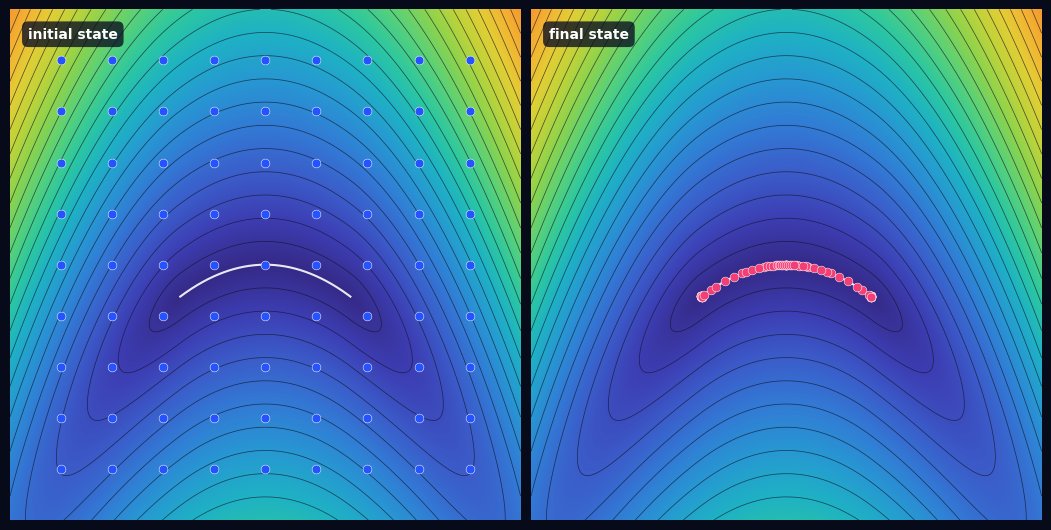

In [4]:
@torch.no_grad()
def sampled_field(config: FlowConfig, grid_size: int | None = None):
    n = grid_size or config.grid_size
    xs = torch.linspace(*config.xlim, n, device=DEVICE, dtype=DTYPE)
    ys = torch.linspace(*config.ylim, n, device=DEVICE, dtype=DTYPE)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    grid = torch.stack((xx, yy), dim=-1)
    distance = banana_potential(grid, config.bend).clamp_min(0).sqrt()
    return xs.cpu().numpy(), ys.cpu().numpy(), distance.cpu().numpy()


def style_field_axis(ax, config: FlowConfig, xs, ys, distance, label: str | None = None):
    ax.imshow(
        distance,
        origin="lower",
        extent=(*config.xlim, *config.ylim),
        cmap=PARULA_LIKE,
        vmin=0,
        vmax=float(distance.max()),
        interpolation="bilinear",
        aspect="auto",              # MATLAB's final `axis square` appearance
        rasterized=True,
    )
    levels = np.linspace(float(distance.min()), float(distance.max()), config.contour_levels)
    ax.contour(xs, ys, distance, levels=levels, colors="#101426", linewidths=0.55, alpha=0.68)

    zero_x = np.linspace(0.0, 1.0, 300)
    zero_y = -config.bend * (zero_x - 0.5) ** 2
    ax.plot(zero_x, zero_y, color="#F8FAFC", linewidth=1.5, alpha=0.92)

    ax.set_xlim(config.xlim)
    ax.set_ylim(config.ylim)
    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    if label:
        ax.text(
            0.035, 0.965, label,
            transform=ax.transAxes,
            ha="left", va="top",
            color="white", fontsize=10, fontweight="semibold",
            bbox=dict(boxstyle="round,pad=0.42", facecolor="#090D22", edgecolor="none", alpha=0.78),
        )


xs, ys, distance = sampled_field(cfg)
path = trajectory.numpy()

fig, axes = plt.subplots(1, 2, figsize=(10.4, 5.2), facecolor="#070A18", constrained_layout=True)
for ax, frame, label in zip(axes, [0, -1], ["initial state", "final state"]):
    style_field_axis(ax, cfg, xs, ys, distance, label)
    ax.scatter(
        path[frame, :, 0], path[frame, :, 1],
        s=40, color="#2453FF" if frame == 0 else "#F43F76",
        edgecolor="white", linewidth=0.35, zorder=5,
    )
plt.show()

## 6. Animation renderer

In [5]:
def blend(a, b, t):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return (1.0 - t[..., None]) * a + t[..., None] * b


def trail_geometry(path: np.ndarray, frame: int):
    if frame <= 0:
        return np.empty((0, 2, 2)), np.empty((0, 4))

    partial = path[: frame + 1]                    # [time, particle, xy]
    segments = np.stack((partial[:-1], partial[1:]), axis=2)
    lengths = np.linalg.norm(np.diff(partial, axis=0), axis=-1)
    cumulative = np.cumsum(lengths, axis=0)
    totals = np.maximum(cumulative[-1:], 1e-12)
    arclength_fraction = cumulative / totals

    # Original blue-to-current color logic, with alpha added for legibility.
    c = frame / max(1, path.shape[0] - 1)
    start_rgb = np.array([0.06, 0.20, 1.00])
    head_rgb = np.array([c, 0.04, 1.0 - c])
    progress = arclength_fraction.reshape(-1)
    rgb = blend(start_rgb, head_rgb, progress)
    alpha = 0.28 + 0.66 * progress
    rgba = np.column_stack((rgb, alpha))
    return segments.reshape(-1, 2, 2), rgba


def build_animation(config: FlowConfig, history: torch.Tensor):
    path = history.detach().cpu().numpy()
    xs, ys, distance = sampled_field(config)
    inches = config.figure_pixels / 100

    fig = plt.figure(figsize=(inches, inches), dpi=100, facecolor="#070A18")
    ax = fig.add_axes([0, 0, 1, 1])
    style_field_axis(ax, config, xs, ys, distance)

    trails = LineCollection([], linewidths=1.15, capstyle="round", joinstyle="round", zorder=4)
    ax.add_collection(trails)
    heads = ax.scatter(
        path[0, :, 0], path[0, :, 1],
        s=58, color="#0F33FF", edgecolor="white", linewidth=0.38, zorder=6,
    )

    mode_name = "normalized flow" if config.mode == "normalized" else "gradient flow"
    label = ax.text(
        0.027, 0.972, f"{mode_name}  ·  bend {config.bend:.2f}",
        transform=ax.transAxes, ha="left", va="top",
        color="white", fontsize=10.5, fontweight="semibold", zorder=8,
        bbox=dict(boxstyle="round,pad=0.43", facecolor="#090D22", edgecolor="none", alpha=0.80),
    )
    counter = ax.text(
        0.973, 0.972, "000 / 130",
        transform=ax.transAxes, ha="right", va="top",
        color="white", fontsize=9.5, family="monospace", zorder=8,
        bbox=dict(boxstyle="round,pad=0.43", facecolor="#090D22", edgecolor="none", alpha=0.80),
    )

    def update(frame: int):
        segments, colors = trail_geometry(path, frame)
        trails.set_segments(segments)
        trails.set_color(colors)
        heads.set_offsets(path[frame])
        c = frame / max(1, path.shape[0] - 1)
        heads.set_facecolor([[c, 0.04, 1.0 - c, 1.0]])
        counter.set_text(f"{frame:03d} / {path.shape[0] - 1:03d}")
        return trails, heads, label, counter

    animation = FuncAnimation(
        fig,
        update,
        frames=range(path.shape[0]),
        interval=1000 / config.fps,
        blit=True,
        repeat=True,
    )
    return fig, animation


print("Animation renderer ready. The next cell writes GIF and MP4, then displays the video.")

Animation renderer ready. The next cell writes GIF and MP4, then displays the video.


## 7. Export an animated GIF and H.264 MP4

The encoder helper uses a system `ffmpeg` when available. If it is absent,
it installs the small `imageio-ffmpeg` wheel and points Matplotlib to its
bundled executable. This works in Colab and in a regular Jupyter environment.

In [6]:
def ensure_ffmpeg() -> str:
    executable = shutil.which("ffmpeg")
    if executable is None:
        try:
            import imageio_ffmpeg
        except ImportError:
            print("ffmpeg was not found; installing the portable encoder …")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "imageio-ffmpeg"])
            importlib.invalidate_caches()
            import imageio_ffmpeg
        executable = imageio_ffmpeg.get_ffmpeg_exe()
    mpl.rcParams["animation.ffmpeg_path"] = executable
    return executable


def export_animation(config: FlowConfig, history: torch.Tensor, output_dir: str | Path):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = f"banana_gradient_flow_bend_{config.bend:.2f}_{config.mode}"
    gif_path = output_dir / f"{stem}.gif"
    raw_gif_path = output_dir / f".{stem}.raw.gif"
    mp4_path = output_dir / f"{stem}.mp4"

    fig, anim = build_animation(config, history)

    print(f"Saving {gif_path.name} …")
    anim.save(
        raw_gif_path,
        writer=PillowWriter(fps=config.fps),
        dpi=100,
        savefig_kwargs={"facecolor": fig.get_facecolor()},
    )

    ffmpeg = ensure_ffmpeg()
    # Re-encode with one optimized palette. This typically shrinks the GIF
    # by 3-5x while preserving all frames and the explicit frame delay.
    try:
        subprocess.run(
            [
                ffmpeg, "-hide_banner", "-loglevel", "error", "-y",
                "-i", str(raw_gif_path),
                "-filter_complex",
                "[0:v]split[a][b];[a]palettegen=max_colors=256:stats_mode=diff[p];"
                "[b][p]paletteuse=dither=sierra2_4a:diff_mode=rectangle",
                "-loop", "0", str(gif_path),
            ],
            check=True,
        )
        raw_gif_path.unlink(missing_ok=True)
    except Exception as error:
        print(f"Palette optimization skipped ({error}).")
        raw_gif_path.replace(gif_path)

    print(f"Saving {mp4_path.name} with {Path(ffmpeg).name} …")
    writer = FFMpegWriter(
        fps=config.fps,
        codec="libx264",
        bitrate=2600,
        extra_args=["-pix_fmt", "yuv420p", "-movflags", "+faststart"],
        metadata={"title": "Banana gradient flow", "artist": "PyTorch + Matplotlib"},
    )
    anim.save(
        mp4_path,
        writer=writer,
        dpi=100,
        savefig_kwargs={"facecolor": fig.get_facecolor()},
    )
    plt.close(fig)
    return gif_path, mp4_path


OUTPUT_DIR = Path("banana_gradient_flow_exports")
gif_path, mp4_path = export_animation(cfg, trajectory, OUTPUT_DIR)

print(f"GIF : {gif_path} ({gif_path.stat().st_size / 1e6:.2f} MB)")
print(f"MP4 : {mp4_path} ({mp4_path.stat().st_size / 1e6:.2f} MB)")
display(Video(str(mp4_path), embed=False, html_attributes="controls loop muted playsinline"))

Saving banana_gradient_flow_bend_1.00_normalized.gif …


Saving banana_gradient_flow_bend_1.00_normalized.mp4 with ffmpeg-macos-aarch64-v7.1 …


GIF : banana_gradient_flow_exports/banana_gradient_flow_bend_1.00_normalized.gif (6.28 MB)
MP4 : banana_gradient_flow_exports/banana_gradient_flow_bend_1.00_normalized.mp4 (1.11 MB)


## 8. Experiments

Change `cfg` and rerun from the simulation cell. A few useful variants:

```python
# Flatter or more strongly bent bananas
cfg = replace(cfg, bend=0.35)
cfg = replace(cfg, bend=2.00)

# Classical, unnormalized gradient flow
cfg = replace(cfg, mode="gradient", frame_step=0.025)

# Denser particles; all are still updated in one PyTorch tensor
cfg = replace(cfg, particles_per_axis=15)

# Match the visible length of the attached 85-frame GIF
cfg = replace(cfg, n_frames=84)
```

The original GIF contains zero-duration frame metadata, so its playback rate
depends on the viewer. These exports deliberately use an explicit `fps` value.